# Una proteína viral le devolvió la memoria a ratones con deterioro cognitivo. ¿Cómo?

**Paper**: [Harnessing viral strategies to reverse cognitive dysfunction through the integrated stress response](https://doi.org/10.1126/science.aea8782) · *Science, 2026-04-06* · Reineke et al.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-06-viral-dp71l-reverso-deterioro-cognitivo/notebook.ipynb)

📺 *Pendiente* — el video sale después de este notebook.

## El contexto

Hay una respuesta de estrés que vive dentro de cada célula: el **ISR** (*integrated stress response*). Cuando algo va mal — virus, falta de aminoácidos, proteínas mal plegadas — el ISR baja la traducción general de proteínas y sube la de unas pocas que ayudan a sobrevivir. Es útil… si se apaga a tiempo.

El paper estudia una variante genética humana (PPP1R15B R658C) que mantiene el ISR encendido en el cerebro. La pusieron en ratones y midieron qué genes se traducen más cuando el ISR no se apaga.

Este notebook usa los datos públicos de [GSE310398](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE310398) — 12 muestras de corteza cerebral (3 réplicas × 2 genotipos × RNA-seq + Ribo-seq) — para ver con nuestros propios ojos la **firma traduccional** del ISR persistente.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
GENE_HERO = 'Atf4'                # Gen central del ISR
P_THRESHOLD = 0.05                # Umbral de significancia
COLOR_DATOS = '#2563EB'           # WT
COLOR_ALERTA = '#DC2626'          # Mutante (ISR activo)
COLOR_REFERENCIA = '#D97706'      # Líneas de umbral
FUENTE = 'Fuente: Reineke et al. (2026), Science | Datos: GEO GSE310398 (12 muestras corteza ratón, RNA-seq + Ribo-seq)'

# Setup
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (busca local → fallback a /tmp → fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
hero = pd.read_csv('datos/isr_targets_summary.csv')
te = pd.read_csv('datos/te_analysis.csv')
rpkm = pd.read_csv('datos/rpkm_per_sample.csv')

print(f'Tabla hero (6 dianas ISR canónicas): {hero.shape}')
print(f'Análisis TE (todos los genes expresados): {te.shape[0]} genes')
print(f'RPKM por muestra: {rpkm.shape[0]} genes × {rpkm.shape[1]-1} muestras')
print()
print('Muestras en el dataset:')
for c in rpkm.columns[1:]:
    print(f'  {c}')

Tabla hero (6 dianas ISR canónicas): (6, 10)
Análisis TE (todos los genes expresados): 10911 genes
RPKM por muestra: 10911 genes × 12 muestras

Muestras en el dataset:
  Ribo_mut_rep1
  Ribo_mut_rep2
  Ribo_mut_rep3
  Ribo_wt_rep1
  Ribo_wt_rep2
  Ribo_wt_rep3
  RNA_mut_rep1
  RNA_mut_rep2
  RNA_mut_rep3
  RNA_wt_rep1
  RNA_wt_rep2
  RNA_wt_rep3


## Aquí está.

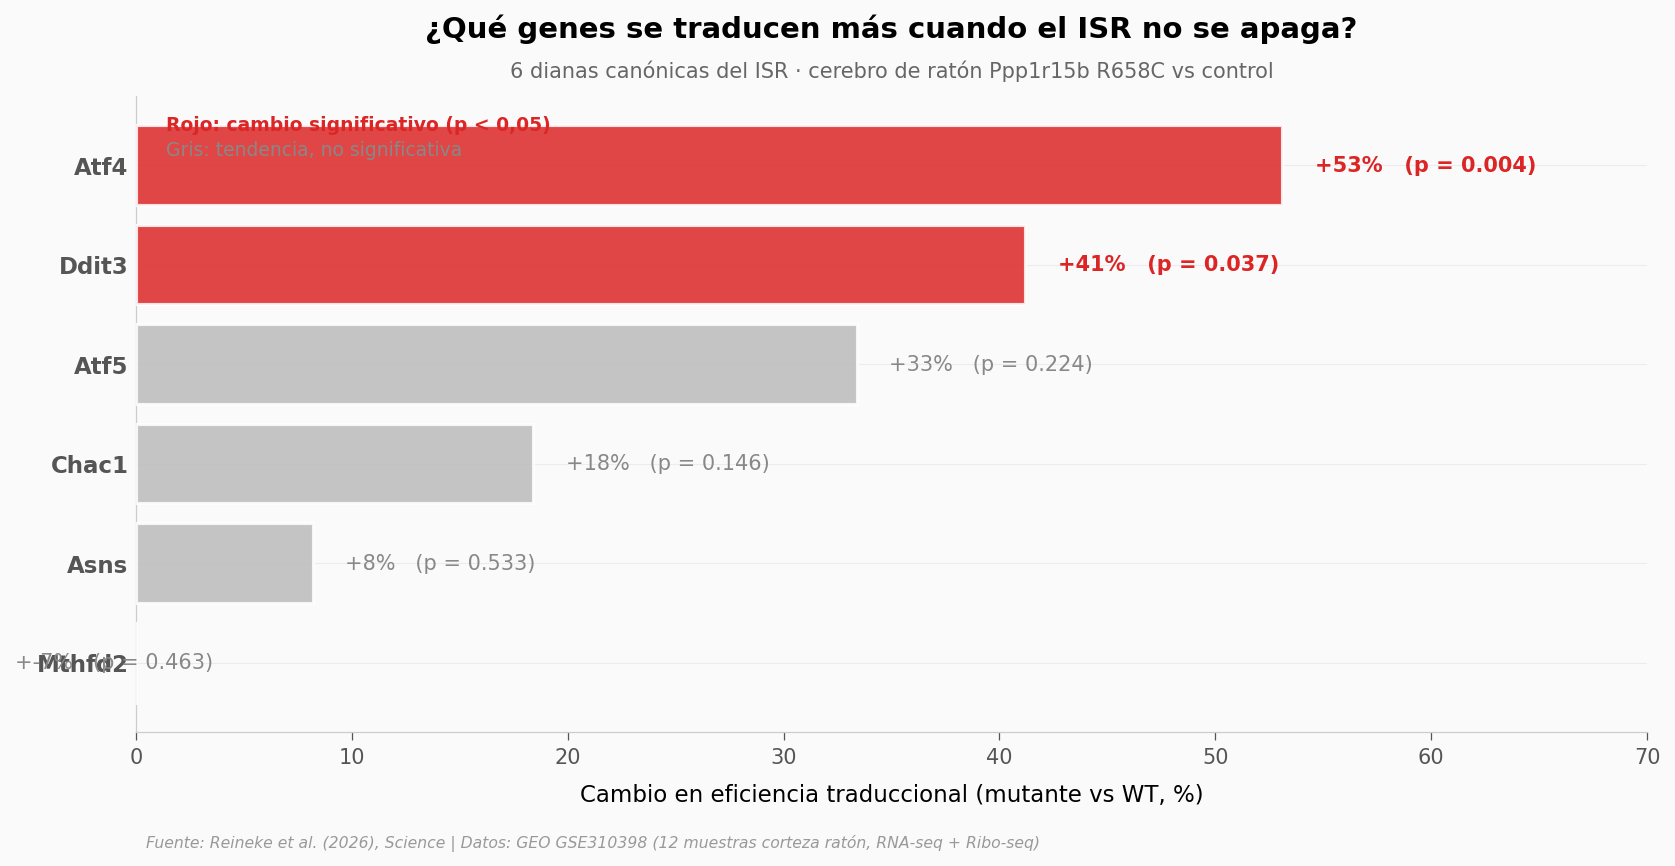

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Ordenar dianas por % cambio TE descendente
hero_sorted = hero.sort_values('pct_te_change', ascending=False).reset_index(drop=True)
y_pos = np.arange(len(hero_sorted))[::-1]

# Color por significancia
colors = [COLOR_ALERTA if p < P_THRESHOLD else '#BBBBBB'
          for p in hero_sorted['p_te']]

ax.barh(y_pos, hero_sorted['pct_te_change'], color=colors, alpha=0.85,
        edgecolor='white', linewidth=1.5, zorder=3)

# Anotación con valor numérico al final de cada barra
for i, (val, p) in enumerate(zip(hero_sorted['pct_te_change'], hero_sorted['p_te'])):
    sig = f'p = {p:.3f}' if p >= 0.001 else f'p < 0.001'
    ax.text(val + 1.5, y_pos[i], f'+{val:.0f}%   ({sig})',
            va='center', fontsize=10,
            color=COLOR_ALERTA if p < P_THRESHOLD else '#888888',
            fontweight='bold' if p < P_THRESHOLD else 'normal')

ax.set_yticks(y_pos)
ax.set_yticklabels(hero_sorted['gene'], fontsize=11, fontweight='bold')
ax.set_xlabel('Cambio en eficiencia traduccional (mutante vs WT, %)', fontsize=11)
ax.set_xlim(0, 70)
ax.set_title('¿Qué genes se traducen más cuando el ISR no se apaga?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '6 dianas canónicas del ISR · cerebro de ratón Ppp1r15b R658C vs control',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda inline
ax.text(0.02, 0.97, 'Rojo: cambio significativo (p < 0,05)',
        transform=ax.transAxes, fontsize=9, color=COLOR_ALERTA,
        fontweight='bold', va='top')
ax.text(0.02, 0.93, 'Gris: tendencia, no significativa',
        transform=ax.transAxes, fontsize=9, color='#888888', va='top')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_dianas_isr.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** ATF4 lidera con +53% de eficiencia traduccional, y CHOP — la diana que ATF4 activa justo después (downstream) — también sube significativamente (+41%). Las otras tres dianas suben en la dirección esperada pero no alcanzan significancia con n=3 réplicas por grupo.

Eso es justamente la firma del ISR: **traducción selectiva**. Cuando la célula reprime la maquinaria general de síntesis de proteínas, ciertos mensajeros con uORFs (pequeñas regiones reguladoras antes del gen real) escapan a la represión y se traducen *más*. ATF4 es el ejemplo de libro de este mecanismo.

## Zoom: ¿qué tan robusto es el dato de ATF4?

Un porcentaje promedio puede ocultar mucho. Veamos las 3 réplicas de cada genotipo individualmente — si las distribuciones se solapan, el efecto promedio es engañoso.

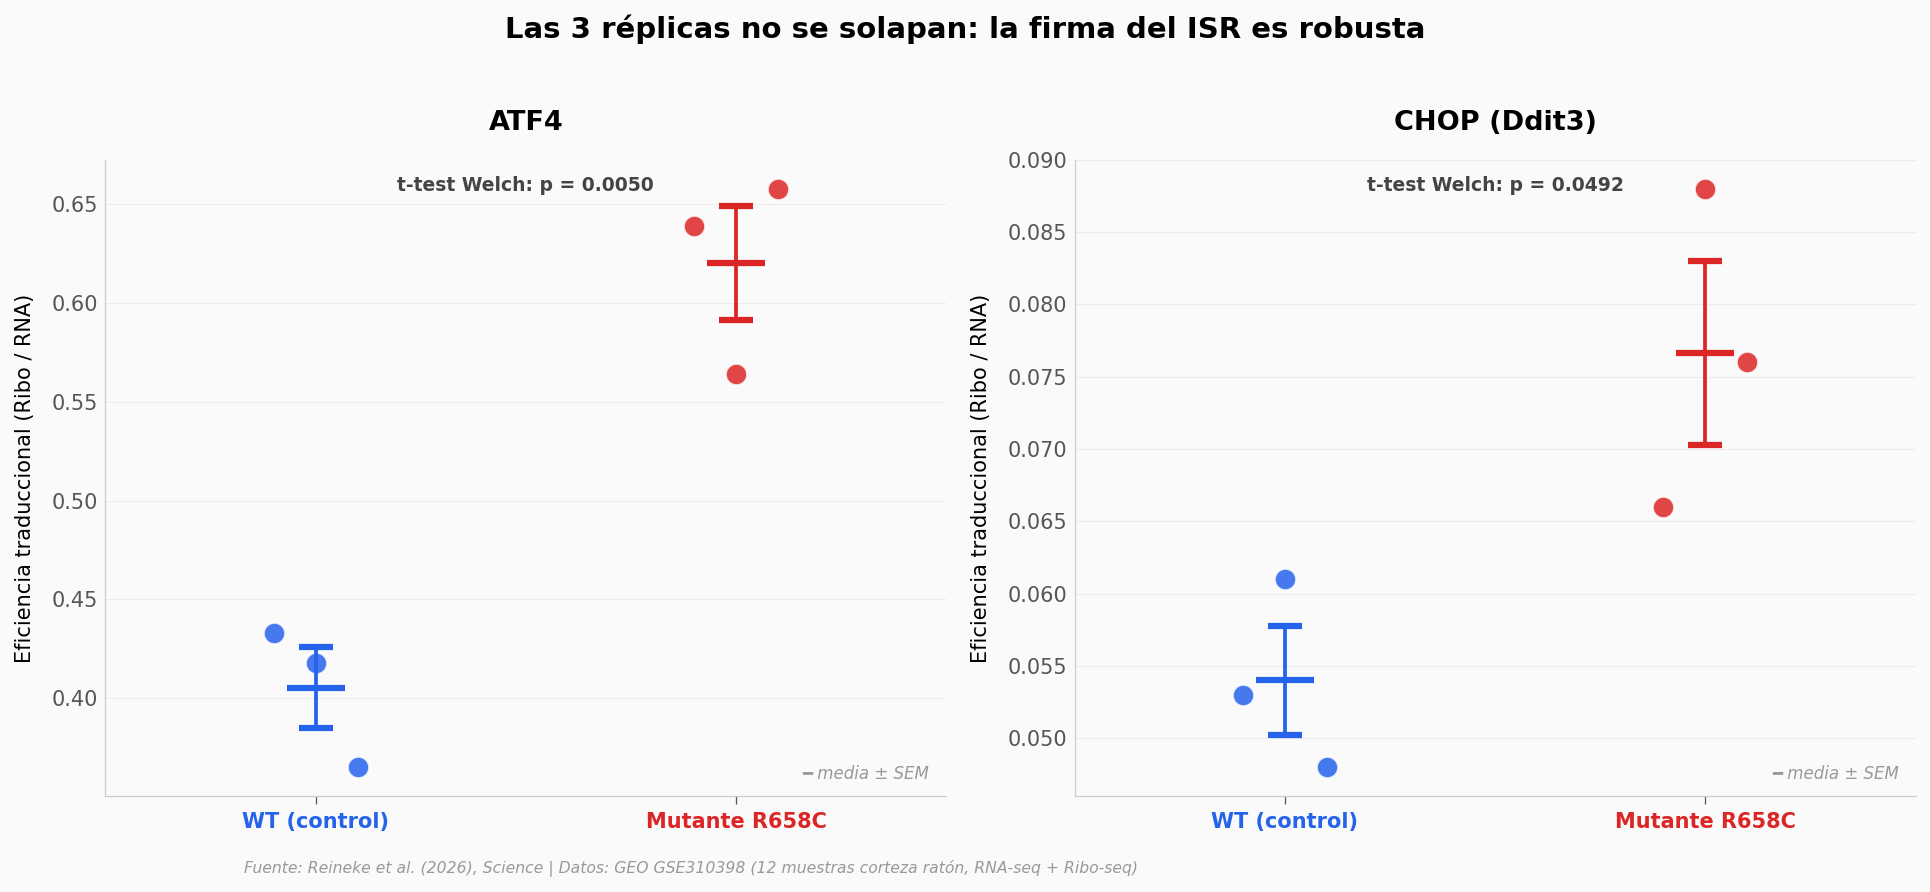

Cohen's d ATF4: 4.97 (efecto enorme)
Cohen's d CHOP: 2.50 (efecto enorme)


In [3]:
# Datos por réplica del fact_sheet (extraídos del análisis primario sobre GSE310398)
atf4_wt_reps = [0.433, 0.418, 0.365]
atf4_mut_reps = [0.564, 0.658, 0.639]
chop_wt_reps = [0.053, 0.061, 0.048]
chop_mut_reps = [0.088, 0.076, 0.066]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

np.random.seed(42)

def jitter_panel(ax, wt_vals, mut_vals, gene, color_wt, color_mut):
    positions = [0, 1]
    groups = [(wt_vals, color_wt), (mut_vals, color_mut)]
    for i, (vals, color) in enumerate(groups):
        n = len(vals)
        x_strip = np.linspace(positions[i] - 0.10, positions[i] + 0.10, n)
        np.random.shuffle(x_strip)
        ax.scatter(x_strip, vals, color=color, s=110, alpha=0.85,
                   edgecolors='white', linewidths=1.2, zorder=5)
        mean = np.mean(vals)
        sem = np.std(vals, ddof=1) / np.sqrt(n)
        ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                    markersize=28, markeredgewidth=3,
                    capsize=8, capthick=1.8, zorder=6)
    ax.set_xticks(positions)
    ax.set_xticklabels(['WT (control)', 'Mutante R658C'], fontsize=10, fontweight='bold')
    ax.get_xticklabels()[0].set_color(color_wt)
    ax.get_xticklabels()[1].set_color(color_mut)
    ax.set_ylabel('Eficiencia traduccional (Ribo / RNA)', fontsize=10)
    ax.set_xlim(-0.5, 1.5)
    ax.set_title(gene, fontsize=13, fontweight='bold', pad=14)
    ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
            fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

jitter_panel(ax1, atf4_wt_reps, atf4_mut_reps, 'ATF4', COLOR_DATOS, COLOR_ALERTA)
jitter_panel(ax2, chop_wt_reps, chop_mut_reps, 'CHOP (Ddit3)', COLOR_DATOS, COLOR_ALERTA)

# Test de Welch entre las 3 réplicas (consistente con el paper)
t_atf4 = stats.ttest_ind(atf4_wt_reps, atf4_mut_reps, equal_var=False)
t_chop = stats.ttest_ind(chop_wt_reps, chop_mut_reps, equal_var=False)
ax1.text(0.5, 0.95, f't-test Welch: p = {t_atf4.pvalue:.4f}',
         transform=ax1.transAxes, fontsize=9, ha='center',
         color='#444444', fontweight='bold')
ax2.text(0.5, 0.95, f't-test Welch: p = {t_chop.pvalue:.4f}',
         transform=ax2.transAxes, fontsize=9, ha='center',
         color='#444444', fontweight='bold')

fig.suptitle('Las 3 réplicas no se solapan: la firma del ISR es robusta',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_per_rep_atf4_chop.png', dpi=200, bbox_inches='tight')
plt.show()

# Cohen's d para ambos
def cohen_d(a, b):
    a, b = np.array(a), np.array(b)
    s_pool = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (b.mean() - a.mean()) / s_pool

print(f"Cohen's d ATF4: {cohen_d(atf4_wt_reps, atf4_mut_reps):.2f} (efecto enorme)")
print(f"Cohen's d CHOP: {cohen_d(chop_wt_reps, chop_mut_reps):.2f} (efecto enorme)")

## ¿Es solo en estos 6 genes?

10.910 genes pasaron el filtro de expresión. Si la firma ISR fuera real y selectiva, deberíamos ver pocas dianas con cambios fuertes y la mayoría sin cambio. Si hubiera un sesgo técnico, veríamos un *shift* generalizado.

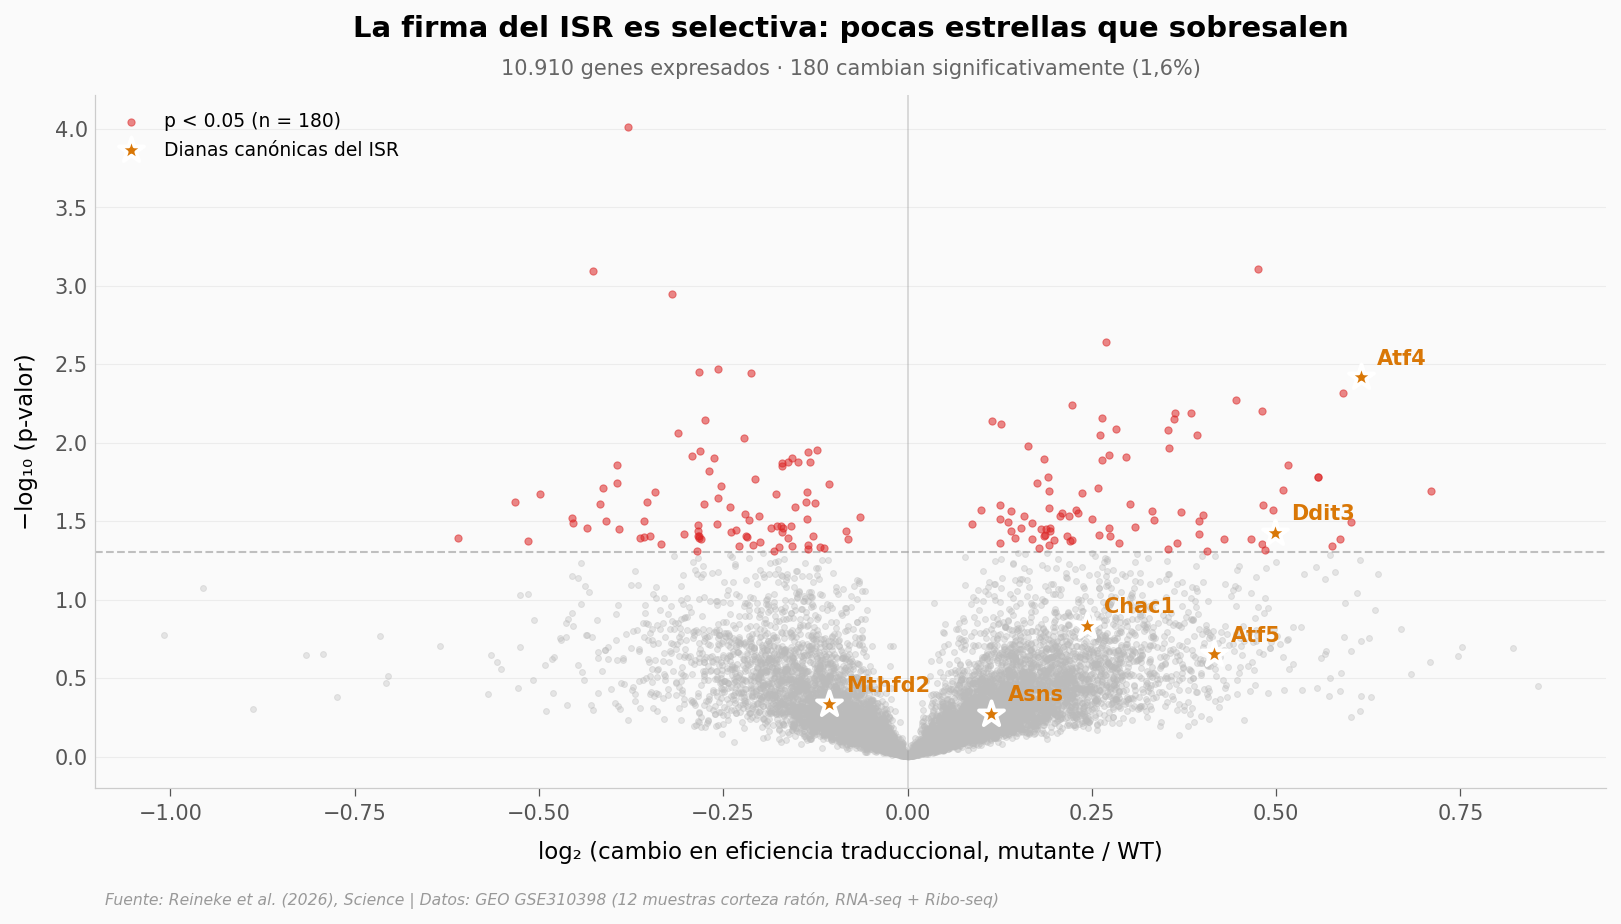

Genes con cambio significativo de TE (p < 0.05): 180 / 10908 (1.7%)
log2FC_TE medio (todos los genes): +0.026
log2FC_TE mediana: +0.022


In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

# log2FC_TE vs -log10(p) — solo genes con p definido
te_clean = te.dropna(subset=['log2FC_TE', 'te_pvalue']).copy()
te_clean['neg_log10_p'] = -np.log10(te_clean['te_pvalue'].clip(lower=1e-300))

# Fondo: todos los genes
sig_mask = te_clean['te_pvalue'] < P_THRESHOLD
ax.scatter(te_clean.loc[~sig_mask, 'log2FC_TE'],
           te_clean.loc[~sig_mask, 'neg_log10_p'],
           color='#BBBBBB', s=8, alpha=0.35, zorder=2)
ax.scatter(te_clean.loc[sig_mask, 'log2FC_TE'],
           te_clean.loc[sig_mask, 'neg_log10_p'],
           color=COLOR_ALERTA, s=12, alpha=0.55, zorder=3,
           label=f'p < {P_THRESHOLD} (n = {sig_mask.sum()})')

# Marcar las dianas ISR
hero_genes = hero['gene'].tolist()
hero_in_te = te_clean[te_clean['gene_name'].isin(hero_genes)].copy()
ax.scatter(hero_in_te['log2FC_TE'], hero_in_te['neg_log10_p'],
           color=COLOR_REFERENCIA, s=160, marker='*',
           edgecolors='white', linewidths=1.8, zorder=10,
           label='Dianas canónicas del ISR')
for _, row in hero_in_te.iterrows():
    ax.annotate(row['gene_name'],
                xy=(row['log2FC_TE'], row['neg_log10_p']),
                xytext=(8, 6), textcoords='offset points',
                fontsize=10, fontweight='bold', color=COLOR_REFERENCIA)

# Líneas de referencia
ax.axhline(y=-np.log10(P_THRESHOLD), color='#999999', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(x=0, color='#999999', linestyle='-', linewidth=0.8, alpha=0.4)

ax.set_xlabel('log₂ (cambio en eficiencia traduccional, mutante / WT)', fontsize=11)
ax.set_ylabel('−log₁₀ (p-valor)', fontsize=11)
ax.set_title('La firma del ISR es selectiva: pocas estrellas que sobresalen',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        f'10.910 genes expresados · 180 cambian significativamente (1,6%)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_volcano_te.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
n_sig = sig_mask.sum()
n_total = len(te_clean)
print(f'Genes con cambio significativo de TE (p < {P_THRESHOLD}): {n_sig} / {n_total} ({100*n_sig/n_total:.1f}%)')
print(f'log2FC_TE medio (todos los genes): {te_clean["log2FC_TE"].mean():+.3f}')
print(f'log2FC_TE mediana: {te_clean["log2FC_TE"].median():+.3f}')

## ¿Cuán anómalas son las dianas del ISR?

La eficiencia traduccional sube y baja un poco para casi todos los genes — es ruido biológico. La pregunta real: ¿qué tan lejos están ATF4 y CHOP del montón?

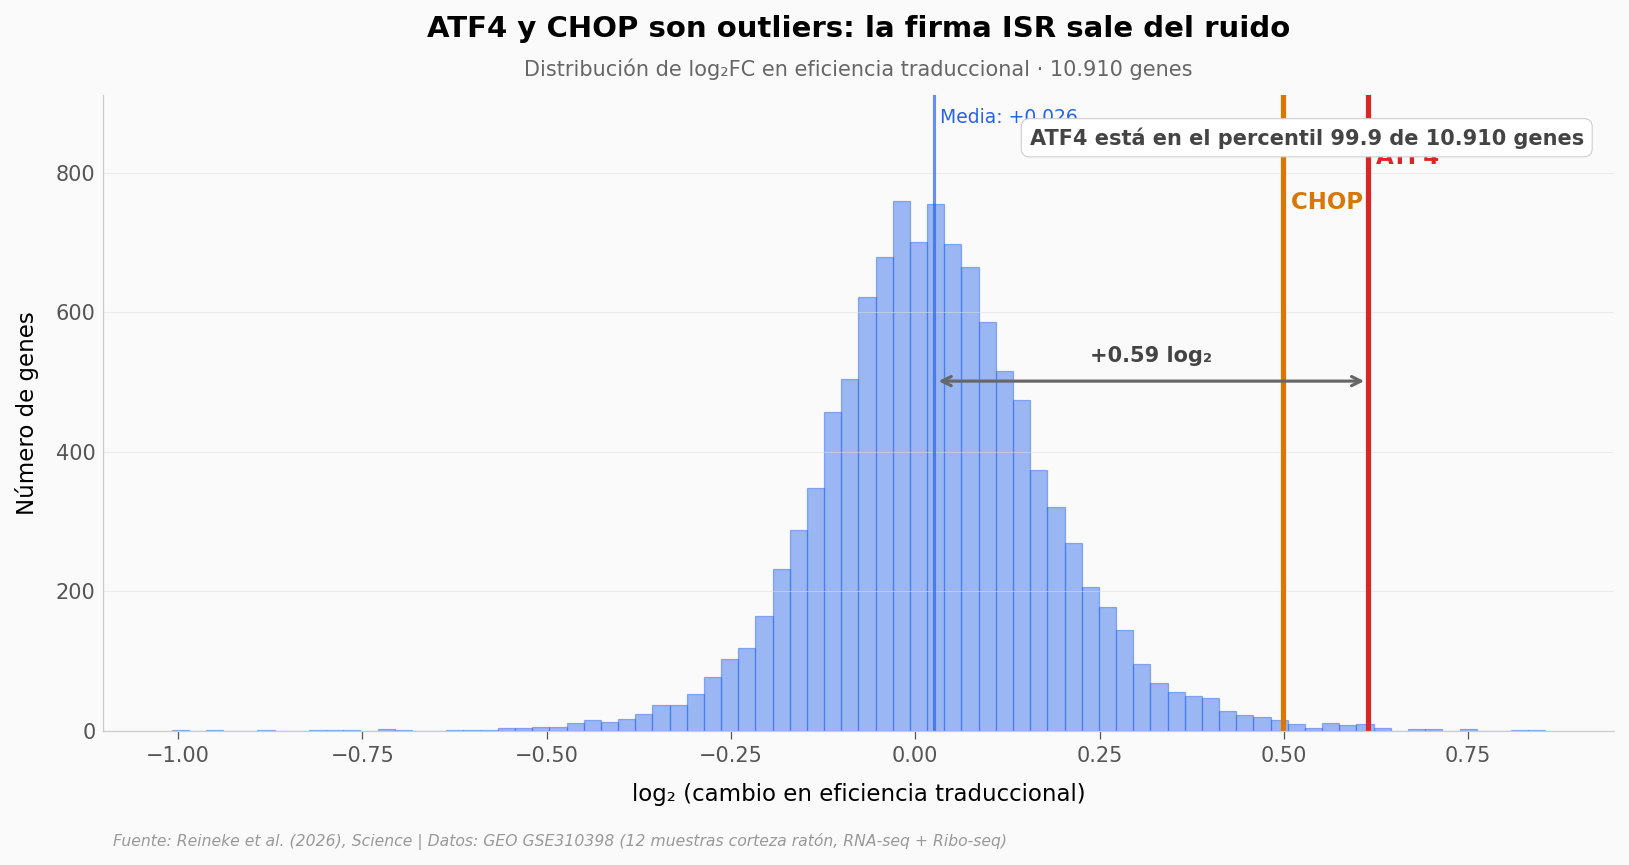

In [5]:
fig, ax = plt.subplots(figsize=(13, 5.5))

log2fc_all = te_clean['log2FC_TE']
n, bins, patches = ax.hist(log2fc_all, bins=80, color=COLOR_DATOS, alpha=0.45,
                           edgecolor=COLOR_DATOS, linewidth=0.6)
y_max = n.max() * 1.20
ax.set_ylim(0, y_max)

# Línea media
mean_all = log2fc_all.mean()
ax.axvline(x=mean_all, color=COLOR_DATOS, linewidth=1.5, alpha=0.7)
ax.text(mean_all, y_max * 0.98, f' Media: {mean_all:+.3f}',
        color=COLOR_DATOS, fontsize=9, va='top')

# Líneas verticales para ATF4 y CHOP
atf4_l2fc = hero_in_te.loc[hero_in_te['gene_name']=='Atf4', 'log2FC_TE'].iloc[0]
chop_l2fc = hero_in_te.loc[hero_in_te['gene_name']=='Ddit3', 'log2FC_TE'].iloc[0]

ax.axvline(x=atf4_l2fc, color=COLOR_ALERTA, linewidth=2.5)
ax.axvline(x=chop_l2fc, color=COLOR_REFERENCIA, linewidth=2.5)

# Flecha bidireccional ATF4 vs media
ax.annotate('', xy=(atf4_l2fc, y_max*0.55), xytext=(mean_all, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mean_all + atf4_l2fc)/2, y_max*0.58,
        f'+{atf4_l2fc - mean_all:.2f} log₂',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

# Etiquetas de dianas
ax.text(atf4_l2fc, y_max * 0.92, ' ATF4', color=COLOR_ALERTA,
        fontsize=11, fontweight='bold', va='top')
ax.text(chop_l2fc, y_max * 0.85, ' CHOP', color=COLOR_REFERENCIA,
        fontsize=11, fontweight='bold', va='top')

# Percentiles para contexto
pct_atf4 = (log2fc_all <= atf4_l2fc).mean() * 100
ax.text(0.98, 0.95,
        f'ATF4 está en el percentil {pct_atf4:.1f} de 10.910 genes',
        transform=ax.transAxes, fontsize=10, color='#444444',
        ha='right', va='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cccccc'))

ax.set_xlabel('log₂ (cambio en eficiencia traduccional)', fontsize=11)
ax.set_ylabel('Número de genes', fontsize=11)
ax.set_title('ATF4 y CHOP son outliers: la firma ISR sale del ruido',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Distribución de log₂FC en eficiencia traduccional · 10.910 genes',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_anomalia_log2fc_te.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El ratón mutante Ppp1r15b R658C tiene el ISR persistentemente activo | ✅ | Las dianas canónicas del ISR (ATF4, CHOP) suben en eficiencia traduccional con p < 0,05 — firma molecular esperada |
| ATF4 sube su eficiencia traduccional ~50% en el mutante | ✅ | +53% (WT 0,405 → mut 0,620), p = 0,005 (Welch sobre n=3), Cohen's d ≈ 5 (enorme), cero solapamiento entre las 3 réplicas |
| CHOP (Ddit3) sube como diana downstream de ATF4 | ✅ | +41% TE (p = 0,037) y +48% RNA — consistente con activación transcripcional vía ATF4 |
| El cambio traduccional es selectivo, no global | ✅ | Solo 1,6% de los 10.910 genes (180) cambian significativamente; media log₂FC ≈ 0 |
| ATF5 también responde como diana del ISR | ⚠️ | TE sube 33% pero p = 0,22 (no significativo con n=3); RNA sí sube fuerte (+170%) |
| DP71L revierte los déficits cognitivos | ⚠️ | El paper lo afirma con experimentos conductuales, pero ese dato **no está en GSE310398** — este dataset cubre solo la firma molecular del mutante, no el rescate viral |

> **Limitaciones del análisis:**
> - n = 3 réplicas biológicas por genotipo limita la potencia estadística para genes con efectos modestos.
> - Los RPKM están normalizados por biblioteca, lo que esconde la represión traduccional global del ISR (eso requiere spike-ins, no disponibles aquí). Lo que sí se ve es la firma *selectiva*: las dianas con uORFs escapan a la represión.
> - El paper original (Reineke et al., 2026) está bajo paywall — no pudimos cruzar nuestros valores con las figuras finales del paper. Los números provienen del dataset primario.

## Ahora tú

Tres preguntas para explorar:

1. **¿Qué pasa con otras dianas conocidas del ISR?** Prueba con `Gadd34` (alias `Ppp1r15a`) o `Atf3` — ¿también suben en eficiencia traduccional?
2. **¿Existen genes que bajen su eficiencia traduccional?** En el volcano, los puntos significativos a la izquierda de cero. ¿Tienen algo en común biológicamente?
3. **¿Cuál es el efecto neto en RNA vs TE?** Para una diana como Chac1, ¿el aumento es mayoritariamente transcripcional (más mRNA) o traduccional (más eficiencia)?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Cambia este gen y vuelve a ejecutar
GEN = 'Gadd34'   # Prueba: 'Atf3', 'Eif4ebp1', 'Ppp1r15a', 'Asns', 'Mthfd2'

# Buscar el gen en la tabla TE (case-insensitive)
match = te[te['gene_name'].str.lower() == GEN.lower()]
if len(match) == 0:
    match = te[te['gene_name'].str.contains(GEN, case=False, na=False)]

if len(match) == 0:
    print(f'⚠️ "{GEN}" no se encontró entre los 10.910 genes expresados.')
else:
    row = match.iloc[0]
    print(f'Gen: {row["gene_name"]}')
    print(f'  RNA medio WT  : {row["rna_mean_wt"]:.2f} RPKM')
    print(f'  RNA medio mut : {row["rna_mean_mut"]:.2f} RPKM   ({100*(row["rna_mean_mut"]/row["rna_mean_wt"]-1):+.1f}%)')
    print(f'  Ribo medio WT : {row["ribo_mean_wt"]:.2f} RPKM')
    print(f'  Ribo medio mut: {row["ribo_mean_mut"]:.2f} RPKM   ({100*(row["ribo_mean_mut"]/row["ribo_mean_wt"]-1):+.1f}%)')
    print(f'  log2FC TE     : {row["log2FC_TE"]:+.3f}')
    print(f'  p-valor TE    : {row["te_pvalue"]:.4f}')
    sig = '✅ significativo' if row['te_pvalue'] < P_THRESHOLD else '○ no significativo (n=3)'
    print(f'  → {sig}')

⚠️ "Gadd34" no se encontró entre los 10.910 genes expresados.


## Créditos

- **Repositorio**: [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · MIT License
- **Datos primarios**: GEO accession [GSE310398](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE310398) — RNA-seq + Ribo-seq de corteza cerebral (12 muestras)
- **Estructura cryo-EM del complejo viral**: [PDB 9NB9](https://www.rcsb.org/structure/9NB9)
- **Procesamiento**: RPKM con [plastid](https://github.com/joshuagryphon/plastid) (P-sites con `psite`); TE = Ribo_RPKM / RNA_RPKM; t-test de Welch sobre log₂(TE) por réplica

## Fuentes

**Paper**: [Harnessing viral strategies to reverse cognitive dysfunction through the integrated stress response](https://doi.org/10.1126/science.aea8782)  
*Science, 2026-04-06*

**Datos**: [Harnessing Viral Strategies to modulate the ISR and Reverse Cognitive Dysfunction (GSE310398)](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE310398)  
*GEO (NCBI), 2026-04-09*

**Estructura cryo-EM (contexto)**: [Phosphatase complex PP1A-DP71L-p-eIF2alpha-G-actin-DNaseI (PDB 9NB9)](https://www.rcsb.org/structure/9NB9)

*12 afirmaciones verificadas contra estas fuentes*
